In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path("..").resolve()
SRC_ROOT = PROJECT_ROOT / "src"

if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

In [2]:
import torch
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader

from palmprint.datasets.bmpd import (
    BMPDDatasetBuilder,
    BMPDDatasetConfig,
    QualityFilterConfig,
    SplitConfig,
)

from palmprint.datasets.pair_dataset import PairDataset
from palmprint.sampling.pairs import generate_balanced_pairs
from palmprint.models.siamese import SiameseNetwork
from palmprint.models.losses import ContrastiveLoss
from palmprint.training.train import train_siamese_model
from palmprint.utils.seed import set_seed

In [4]:
set_seed(42)

DATA_ROOT = PROJECT_ROOT / "data" / "processed" / "bmpd_roi"
CHECKPOINT_PATH = PROJECT_ROOT / "checkpoints" / "siamese_bmpd_roi_best.pt"
QUALITY_CSV_PATH = PROJECT_ROOT / "data" / "qc" / "roi_quality.csv"

IMAGE_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 0
NUM_EPOCHS = 20
LEARNING_RATE = 1e-3
EMBEDDING_DIM = 128

TRAIN_PAIRS = 10_000
VAL_PAIRS = 2_000

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [7]:
config = BMPDDatasetConfig(
    roi_dir=DATA_ROOT,
    split=SplitConfig(
        seed=42,
        train_ratio=0.7,
        val_ratio=0.1,
        test_ratio=0.2,
    ),
    quality_filter=QualityFilterConfig(
        apply_quality_filter=True,
        project_root=PROJECT_ROOT,
        quality_csv_path=QUALITY_CSV_PATH,
        verbose=True,
    ),
)

builder = BMPDDatasetBuilder(config)

splits = builder.build_splits()

for split_name, samples in splits.items():
    identities = sorted({sample.identity_id for sample in samples})
    print(f"{split_name}: {len(samples)} images, {len(identities)} identities")


=== ROI QUALITY FILTERING ===
Total images:     1612
Removed (bad):    89
Kept:             1523
Percent removed:  5.52%
train: 1071 images, 56 identities
val: 148 images, 8 identities
test: 304 images, 16 identities


In [8]:
train_pairs = generate_balanced_pairs(
    splits["train"],
    num_pairs=TRAIN_PAIRS,
    seed=42,
)

val_pairs = generate_balanced_pairs(
    splits["val"],
    num_pairs=VAL_PAIRS,
    seed=43,
)

print(f"Train pairs: {len(train_pairs)}")
print(f"Val pairs: {len(val_pairs)}")

Train pairs: 10000
Val pairs: 2000


In [9]:
from collections import Counter

print("Train pair labels:", Counter(label for _, _, label in train_pairs))
print("Val pair labels:", Counter(label for _, _, label in val_pairs))

Train pair labels: Counter({1: 5000, 0: 5000})
Val pair labels: Counter({1: 1000, 0: 1000})


In [10]:
train_dataset = PairDataset(
    train_pairs,
    image_size=IMAGE_SIZE,
    grayscale=True,
)

val_dataset = PairDataset(
    val_pairs,
    image_size=IMAGE_SIZE,
    grayscale=True,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
)

In [11]:
img1, img2, labels = next(iter(train_loader))

print("img1:", img1.shape)
print("img2:", img2.shape)
print("labels:", labels.shape)
print("label examples:", labels[:10])

img1: torch.Size([32, 1, 224, 224])
img2: torch.Size([32, 1, 224, 224])
labels: torch.Size([32])
label examples: tensor([0., 1., 0., 0., 0., 0., 0., 0., 1., 1.])


In [9]:
model = SiameseNetwork(
    embedding_dim=EMBEDDING_DIM,
    input_channels=1,
)

criterion = ContrastiveLoss(margin=1.0)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
)

In [10]:
history = train_siamese_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    num_epochs=NUM_EPOCHS,
    checkpoint_path=CHECKPOINT_PATH,
)

Epoch 001/20 | train_loss=0.1730 | val_loss=0.2114
Saved best model to C:\Users\cameron.ortiz\OneDrive - Rackspace Inc\Documents\school_work\deep_learning\palm_print_project\palmprint-verification-siamese\checkpoints\siamese_bmpd_roi_best.pt
Epoch 002/20 | train_loss=0.1489 | val_loss=0.2558
Epoch 003/20 | train_loss=0.1310 | val_loss=0.2184
Epoch 004/20 | train_loss=0.1164 | val_loss=0.1861
Saved best model to C:\Users\cameron.ortiz\OneDrive - Rackspace Inc\Documents\school_work\deep_learning\palm_print_project\palmprint-verification-siamese\checkpoints\siamese_bmpd_roi_best.pt
Epoch 005/20 | train_loss=0.1072 | val_loss=0.2174
Epoch 006/20 | train_loss=0.0993 | val_loss=0.1752
Saved best model to C:\Users\cameron.ortiz\OneDrive - Rackspace Inc\Documents\school_work\deep_learning\palm_print_project\palmprint-verification-siamese\checkpoints\siamese_bmpd_roi_best.pt
Epoch 007/20 | train_loss=0.0910 | val_loss=0.1938
Epoch 008/20 | train_loss=0.0847 | val_loss=0.2066
Epoch 009/20 | trai

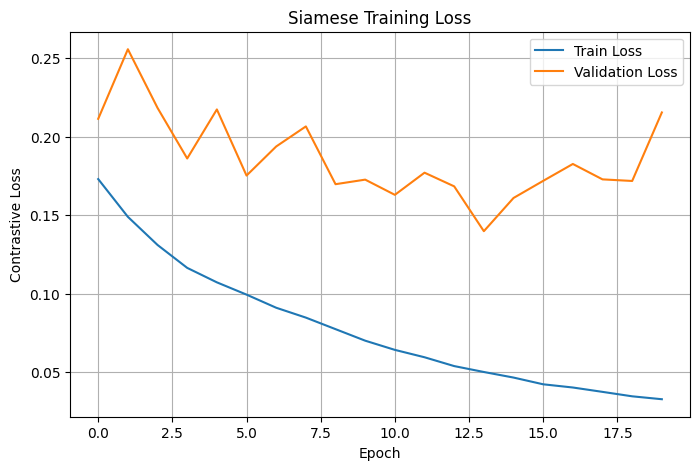

In [11]:
plt.figure(figsize=(8, 5))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Contrastive Loss")
plt.title("Siamese Training Loss")
plt.legend()
plt.grid(True)
plt.show()

In [12]:
CHECKPOINT_PATH.exists(), CHECKPOINT_PATH

(True,
 WindowsPath('C:/Users/cameron.ortiz/OneDrive - Rackspace Inc/Documents/school_work/deep_learning/palm_print_project/palmprint-verification-siamese/checkpoints/siamese_bmpd_roi_best.pt'))

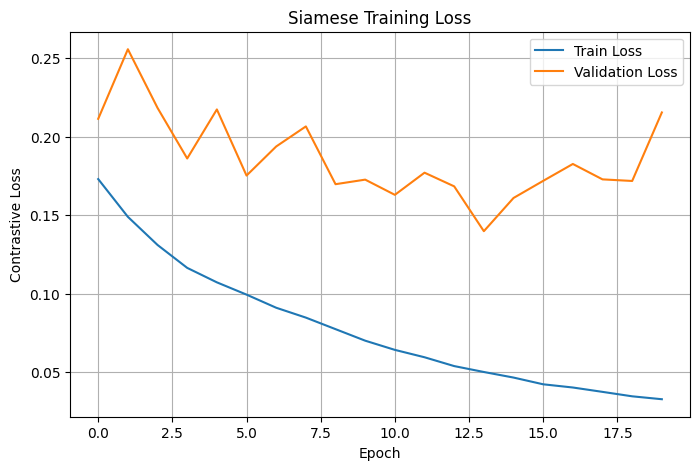

WindowsPath('C:/Users/cameron.ortiz/OneDrive - Rackspace Inc/Documents/school_work/deep_learning/palm_print_project/palmprint-verification-siamese/reports/figures/siamese_training_loss.png')

In [13]:
FIGURE_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(8, 5))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Contrastive Loss")
plt.title("Siamese Training Loss")
plt.legend()
plt.grid(True)

out_path = FIGURE_DIR / "siamese_training_loss.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

out_path